In [20]:
"""
Baseline Random Forest — Intrusion Detection System

This notebook establishes the baseline performance of a Random Forest classifier
on the NSL-KDD network intrusion dataset without any dimensionality reduction.

Dataset
- Source: NSL-KDD
- Raw columns: 43 (41 features + label + difficulty)
- After dropping label and difficulty: 41 features
- After one-hot encoding: 122 features
- Train/test split: 80% / 20%

Models
- Model A: Random Forest trained on all 122 features 
- Model B: Random Forest trained on top N features by importance (N = 10, 15, 20, 30)
"""

'\nBaseline Random Forest — Intrusion Detection System\n\nThis notebook establishes the baseline performance of a Random Forest classifier\non the NSL-KDD network intrusion dataset without any dimensionality reduction.\n\nDataset\n- Source: NSL-KDD\n- Raw columns: 43 (41 features + label + difficulty)\n- After dropping label and difficulty: 41 features\n- After one-hot encoding: 122 features\n- Train/test split: 80% / 20%\n\nModels\n- Model A: Random Forest trained on all 122 features \n- Model B: Random Forest trained on top N features by importance (N = 10, 15, 20, 30)\n'

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

df = pd.read_csv("../data/KDDTrain+.txt", names=columns, sep="\t")
print("Raw shape:", df.shape)
df.head()

Raw shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
y = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

X = df.drop(['label', 'difficulty'], axis=1)
X = pd.get_dummies(X)

print("Features after encoding:", X.shape)

Features after encoding: (125973, 122)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((100778, 122), (25195, 122))

In [4]:
# Model A (Baseline - Full Features)
rf_full = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_full.fit(X_train, y_train)
end = time.time()

baseline_train_time = end - start
print("Model A — Training Time:", baseline_train_time, "seconds")

Model A — Training Time: 11.9098060131073 seconds


In [5]:
y_pred_full = rf_full.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_full)

print("Model A — Accuracy:", baseline_accuracy)
print("\nClassification Report (Model A):")
print(classification_report(y_test, y_pred_full))

Model A — Accuracy: 0.9990871204604088

Classification Report (Model A):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



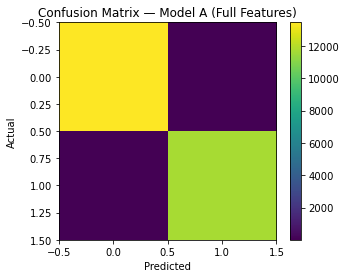

In [6]:
cm_full = confusion_matrix(y_test, y_pred_full)

plt.figure(figsize=(5,4))
plt.imshow(cm_full)
plt.title("Confusion Matrix — Model A (Full Features)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Top 20 Features (Model A):
                         feature  importance
1                      src_bytes    0.143524
120                      flag_SF    0.092945
2                      dst_bytes    0.077351
30        dst_host_same_srv_rate    0.054713
25                 same_srv_rate    0.051096
29            dst_host_srv_count    0.049829
8                      logged_in    0.049315
26                 diff_srv_rate    0.044636
35      dst_host_srv_serror_rate    0.039537
22               srv_serror_rate    0.032163
19                         count    0.027816
38            protocol_type_icmp    0.027307
31        dst_host_diff_srv_rate    0.025114
32   dst_host_same_src_port_rate    0.023743
21                   serror_rate    0.022712
33   dst_host_srv_diff_host_rate    0.020735
28                dst_host_count    0.018373
65                  service_http    0.017864
90               service_private    0.016449
116                      flag_S0    0.014786


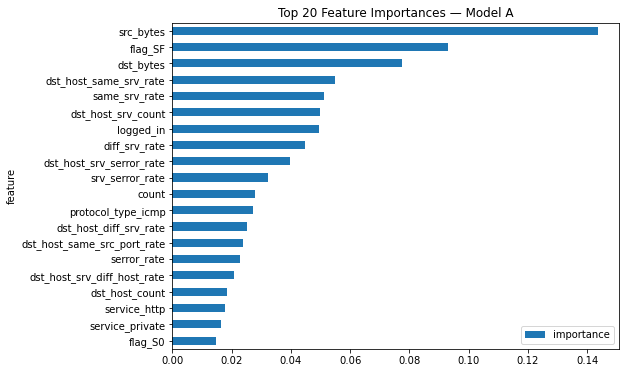

In [7]:
feature_importance_full = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_full.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 Features (Model A):")
print(feature_importance_full.head(20))

feature_importance_full.to_csv("feature_importance_full.csv", index=False)

feature_importance_full.head(20).plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(8,6)
)
plt.title("Top 20 Feature Importances — Model A")
plt.gca().invert_yaxis()
plt.show()

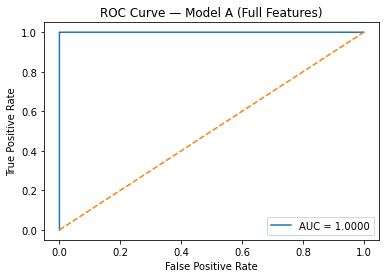

In [8]:
#ROC Curve

y_probs_full = rf_full.predict_proba(X_test)[:, 1]
fpr_full, tpr_full, _ = roc_curve(y_test, y_probs_full)
roc_auc_full = auc(fpr_full, tpr_full)

plt.figure()
plt.plot(fpr_full, tpr_full, label=f"AUC = {roc_auc_full:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model A (Full Features)")
plt.legend()
plt.show()

In [9]:
baseline_results = pd.DataFrame([{
    "model": "A_full_features",
    "accuracy": baseline_accuracy,
    "train_time": baseline_train_time,
    "auc": roc_auc_full
}])

baseline_results.to_csv("baseline_results_modelA.csv", index=False)
baseline_results

,model,accuracy,train_time,auc
0,A_full_features,0.999087,11.909806,0.999995


In [11]:
#Model B (Top N Features - No PCA)

feature_counts = [10, 15, 20, 30]
results_b = []

for n in feature_counts:
    top_features = feature_importance_full.head(n)['feature']
    X_subset = X[top_features]

    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_subset, y, test_size=0.2, random_state=42, stratify=y
    )

    rf_b = RandomForestClassifier(n_estimators=100, random_state=42)

    start = time.time()
    rf_b.fit(X_train_b, y_train_b)
    end = time.time()

    y_pred_b = rf_b.predict(X_test_b)

    acc_b = accuracy_score(y_test_b, y_pred_b)
    train_time_b = end - start

    results_b.append({
        "model": f"B_top_{n}",
        "features": n,
        "accuracy": acc_b,
        "train_time": train_time_b
    })
results_b_df = pd.DataFrame(results_b)
results_b_df

,model,features,accuracy,train_time
0,B_top_10,10,0.997817,12.197241
1,B_top_15,15,0.998174,11.676825
2,B_top_20,20,0.998611,12.370924
3,B_top_30,30,0.998889,14.586871


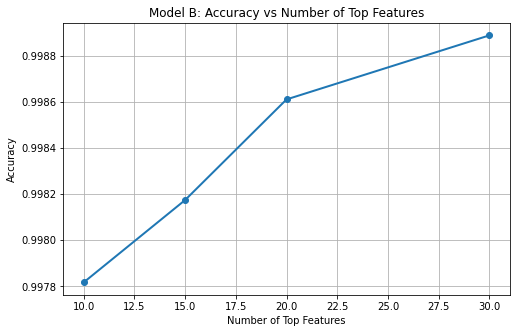

In [12]:
plt.figure(figsize=(8,5))
plt.plot(results_b_df['features'], results_b_df['accuracy'], marker='o', linewidth=2)
plt.title("Model B: Accuracy vs Number of Top Features")
plt.xlabel("Number of Top Features")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

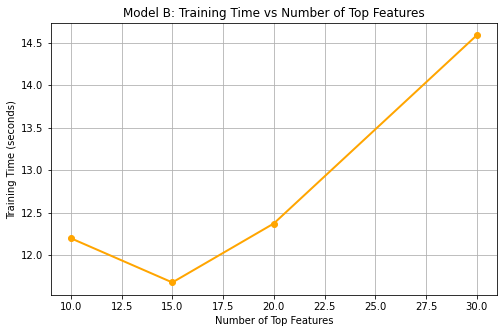

In [13]:
plt.figure(figsize=(8,5))
plt.plot(results_b_df['features'], results_b_df['train_time'], marker='o', color='orange', linewidth=2)
plt.title("Model B: Training Time vs Number of Top Features")
plt.xlabel("Number of Top Features")
plt.ylabel("Training Time (seconds)")
plt.grid(True)
plt.show()

In [13]:
results_b_df.to_csv("reduced_feature_results_modelB.csv", index=False)